In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db = mysql.connector.connect(host = "localhost",
                             username = "root",
                             password = "Oishi@03",
                             database = "ecommerce")
cur = db.cursor()


# List all unique cities where customers are located. 

In [55]:
query = """select distinct customer_city City from ecommerce.customers"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["City"])
df

,City
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas
...,...
4114,siriji
4115,natividade da serra
4116,monte bonito
4117,sao rafael


# Count the number of orders placed in 2017.

In [8]:
query = """select count(order_id) from ecommerce.orders where order_purchase_timestamp = 2017"""
cur.execute(query)
data = cur.fetchall()

"Total orders placed in 2017 are",data[0][0]

('Total orders placed in 2017 are', 45101)

# Find the total sales per category.

In [31]:
query = """select products.product_category category, round(sum(payments.payment_value),2)sales 
from products inner join order_items 
on products.product_id= order_items.product_id
join payments on payments.order_id = order_items.order_id group by product_category"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns= ["Category", "Sales"])
df

,Category,Sales
0,perfumery,506738.66
1,Furniture Decoration,1430176.39
2,telephony,486882.05
3,bed table bath,1712553.67
4,automotive,852294.33
...,...,...
69,cds music dvds,1199.43
70,La Cuisine,2913.53
71,Fashion Children's Clothing,785.67
72,PC Gamer,2174.43


# Calculate the percentage of orders that were paid in installments.

In [33]:
query = """select (sum(case when payment_installments>=1 then 1 else 0 end))/count(*)*100 from payments"""
cur.execute(query)
data = cur.fetchall()

"The percentage of orders that were paid in installments are ",data[0][0]

('The percentage of orders that were paid in installments are ',
 Decimal('99.9981'))

# Count the number of customers from each state. 

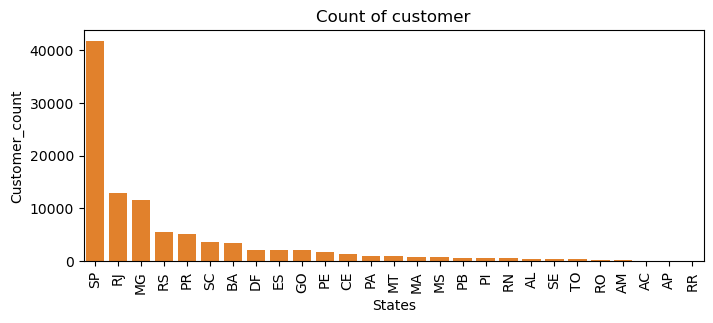

In [47]:
query = """select customer_state, count(customer_id) from customers group by customer_state"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns= ["States", "Customer_count"])
df = df.sort_values (by = "Customer_count", ascending = False)
plt.figure(figsize = (8,3))
plt.bar(df["States"], df["Customer_count"])
plt.xticks(rotation = 90)
plt.title("Count of customer")
sns.barplot(x = df["States"], y = df["Customer_count"])
plt.show()

# Calculate the number of orders per month in 2018.

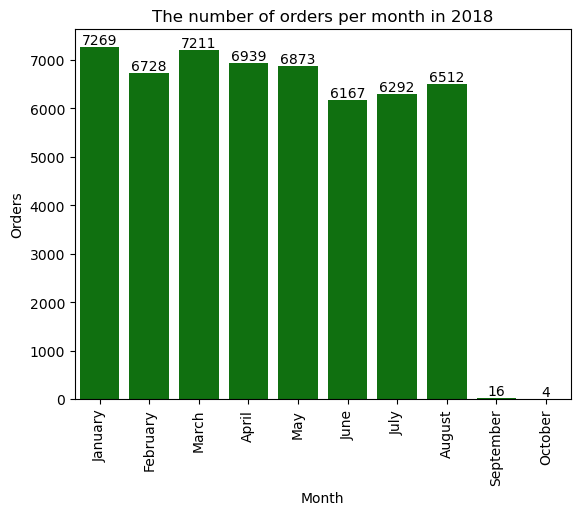

In [20]:
query = """select monthname(order_purchase_timestamp) as months, count(order_id) from ecommerce.orders 
where year(order_purchase_timestamp) = 2018 
group by months"""
cur.execute(query)
data = cur.fetchall()
data
df = pd.DataFrame(data, columns = ["Month", "Orders"])
o = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October"]
plt.title("The number of orders per month in 2018")
ax = sns.barplot(x = df["Month"], y= df["Orders"], data = df, order = o, color = "green")
plt.xticks(rotation = 90)
ax.bar_label(ax.containers[0])
plt.show()

# Find the average number of products per order, grouped by customer city.

In [65]:
query = """select customers.customer_city, AVG(product_count)
from(select orders.order_id, orders.customer_id, count(order_items.product_id) as product_count from orders
join order_items on orders.order_id = order_items.order_id group by order_id, customer_id)as temp
join customers on temp.customer_id = customers.customer_id group by customer_city"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["City", "avg_product"])
df

,City,avg_product
0,sao paulo,1.1562
1,sao jose dos campos,1.1385
2,porto alegre,1.1749
3,indaial,1.1154
4,treze tilias,1.2727
...,...,...
4105,japaratuba,1.0000
4106,sebastiao leal,1.0000
4107,buriti,3.0000
4108,morro agudo de goias,1.0000


# Calculate the percentage of total revenue contributed by each product category.

In [6]:
query = """SELECT 
    products.product_category,
    round((SUM(payments.payment_value) / MAX(total.total_revenue) * 100),2) AS revenue_percentage
FROM products
JOIN order_items ON products.product_id = order_items.product_id
JOIN payments ON payments.order_id = order_items.order_id
JOIN (
    SELECT SUM(payment_value) AS total_revenue
    FROM payments
)as total
GROUP BY products.product_category;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Product category", "Revenue percentage"])
df

,Product category,Revenue percentage
0,perfumery,3.17
1,Furniture Decoration,8.93
2,telephony,3.04
3,bed table bath,10.70
4,automotive,5.32
...,...,...
69,cds music dvds,0.01
70,La Cuisine,0.02
71,Fashion Children's Clothing,0.00
72,PC Gamer,0.01


# Identify the correlation between product price and the number of times a product has been purchased.

In [62]:
query = """select product_category, count(products.product_id), round(AVG(order_items.price),2) from products 
join order_items on products.product_id = order_items.product_id
group by products.product_category"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Product category", "No. of products", "Product price"])
df
arr1 = df["No. of products"]
arr2 = df["Product price"]
a = np.corrcoef([arr1, arr2])
print("The correlation between them is ", a[0][1])

The correlation between them is  -0.10631514167157562


# Calculate the total revenue generated by each seller, and rank them by revenue.

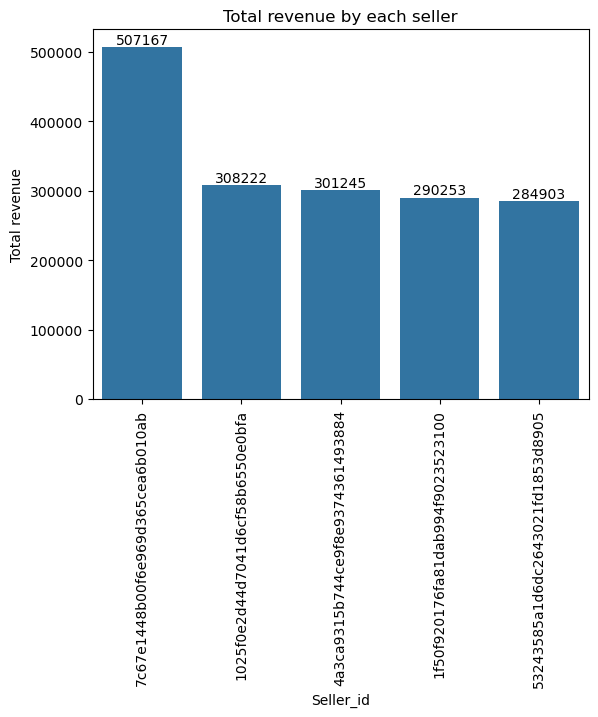

In [19]:
query = """select *, dense_rank() over(order by revenue desc) from
(select order_items.seller_id, sum(payments.payment_value) revenue from order_items
join payments on order_items.order_id = payments.order_id
group by order_items.seller_id) as generator"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["Seller_id","Total revenue", "Rank by revenue"])
df = df.head()
df = df.sort_values("Total revenue", ascending = False)
plt.xticks(rotation = 90)
ax = sns.barplot(x = "Seller_id", y = "Total revenue", data = df)
ax.bar_label(ax.containers[0])
plt.title("Total revenue by each seller")
plt.show()


# Calculate the moving average of order values for each customer over their order history.

In [91]:
query = """select customer_id, order_purchase_timestamp, order_value,
AVG(order_value) OVER(
PARTITION BY customer_id
ORDER BY order_purchase_timestamp
ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) as moving_avg_order_value from
(select orders.customer_id, orders.order_purchase_timestamp, payments.payment_value as order_value
from orders join payments on orders.order_id = payments.order_id) as a"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Customer_id", "Order hitory", "Order value", "Moving avg"])
df


,Customer_id,Order hitory,Order value,Moving avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


# Calculate the cumulative sales per month for each year.

In [32]:
query = """select yearly, monthly, payment,
sum(payment) over(
partition by yearly
order by monthly
rows between 2 preceding and current row) as cumilative_sales from
(select year(orders.order_purchase_timestamp) as yearly, month(orders.order_purchase_timestamp) as monthly, 
sum(payments.payment_value) as payment from orders 
join payments on orders.order_id = payments.order_id
group by year(orders.order_purchase_timestamp), month(orders.order_purchase_timestamp)) as a"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Year", "Month", "Payment", "Cumilative sum"])
df

,Year,Month,Payment,Cumilative sum
0,2016,9,252.24,252.24
1,2016,10,"59,090.48","59,342.72"
2,2016,12,19.62,"59,362.34"
3,2017,1,"138,488.04","138,488.04"
4,2017,2,"291,908.01","430,396.05"
5,2017,3,"449,863.60","880,259.65"
6,2017,4,"417,788.03","1,159,559.64"
7,2017,5,"592,918.82","1,460,570.45"
8,2017,6,"511,276.38","1,521,983.23"
9,2017,7,"592,382.92","1,696,578.12"


# Calculate the year-over-year growth rate of total sales.

In [42]:
query = """select year,
((total_sales - lag(total_sales) over(order by year))
/lag(total_sales) over(order by year)) * 100 as growth_rate from
(select year(orders.order_purchase_timestamp) as year, sum(payments.payment_value) as total_sales from orders
join payments on orders.order_id = payments.order_id
group by year) as a"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Year", "Growth rate"])
df

,Year,Growth rate
0,2016,NaN
1,2017,"12,112.70"
2,2018,20.00


# Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [27]:
query = """select(
count(distinct required_customer.customer_id)/count(distinct all_customer.customer_id)*100)
from orders all_customer
left join (select distinct orders.customer_id from orders
join (select orders.customer_id, min(orders.order_purchase_timestamp) as first_order_date from orders
group by orders.customer_id) as first_order
on orders.customer_id = first_order.customer_id
where orders.order_purchase_timestamp > first_order.first_order_date
AND orders.order_purchase_timestamp <= DATE_ADD(first_order.first_order_date, INTERVAL 6 month)) as required_customer
on all_customer.customer_id = required_customer.customer_id"""
cur.execute(query)
data = cur.fetchall()

data

[(Decimal('0.0000'),)]

# Identify the top 3 customers who spent the most money in each year.

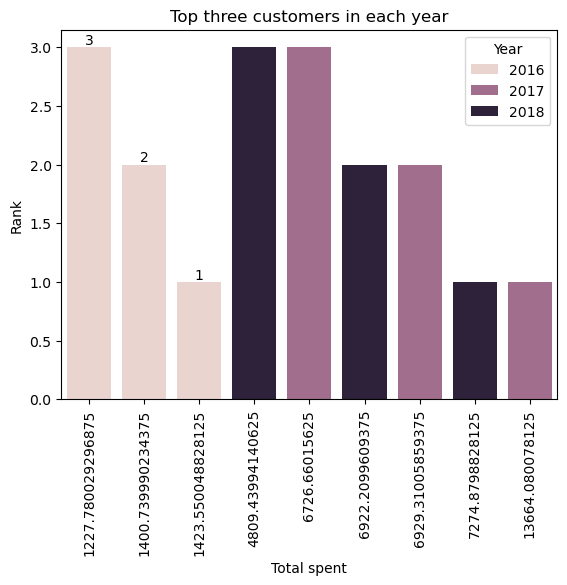

In [18]:
query = """select customer_id, year, total_spent, rnk from
(select orders.customer_id, year(orders.order_purchase_timestamp) as year, sum(payments.payment_value) as total_spent,
DENSE_RANK() OVER(
PARTITION BY year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc
) as rnk
from orders join payments on orders.order_id = payments.order_id
group by year(orders.order_purchase_timestamp), orders.customer_id) rnk_customers
where rnk <= 3
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Customer id", "Year", "Total spent", "Rank"])
ax = sns.barplot(x = "Total spent", y = "Rank", data = df, hue = "Year")
ax.bar_label(ax.containers[0])
plt.xticks(rotation = 90)
plt.title("Top three customers in each year")
plt.show()